# 03. Seaborn Statistical Plots
## 📚 Learning Objectives

By completing this notebook, you will:
- Build statistical plots with Seaborn
- Use built-in themes and palettes
- Combine Seaborn with pandas DataFrames

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

## 🔗 Solving the Problem from Example 2

**Remember the dead end from Example 2?**
- We learned matplotlib for creating static plots
- But matplotlib was verbose for statistical visualizations
- Creating statistical plots required many lines of code

**This notebook solves that problem!**
- We'll learn **Seaborn** - simplifies statistical plots
- We'll see the same plots created with **much less code**
- We'll learn **beautiful default styles** for statistical visualizations

**This solves the verbosity problem from Example 2!**

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 2: Matplotlib Fundamentals** - Seaborn builds on matplotlib!
- ✅ **Understanding of statistical concepts** (distributions, correlations)

**If you haven't completed these**, you might struggle with:
- Understanding what Seaborn adds to matplotlib
- Knowing which statistical plot to use
- Understanding statistical visualizations

---

## 🔗 Where This Notebook Fits

**This is Example 03 in Unit 3** - it solves the problem from Example 02!

**Why this example SECOND?**
- **Before** using Seaborn, you need matplotlib knowledge (Seaborn is built on it)
- **Before** interactive plots, master statistical visualizations
- Seaborn makes statistical plots much easier than raw matplotlib

**Builds on**: 
- 📓 Example 2: Matplotlib Fundamentals (we hit the verbosity dead end, now Seaborn solves it)

**Leads to**: 
- 📓 Example 4: Plotly Interactive (different approach - interactive vs static)
- 📓 Statistical analysis (Seaborn is perfect for exploring data relationships)

**Why this order?**
1. Matplotlib first (foundation that Seaborn builds on)
2. Seaborn second (statistical visualizations made easier)
3. Plotly third (interactive visualizations)

---

## The Story: Better Tools Make Better Art

Imagine you're painting. **Basic brushes work**, but specialized brushes make painting 
easier and results more beautiful. **After** learning specialized tools, you create better art!

Same with visualization: Matplotlib works, but Seaborn (specialized for statistics) 
makes statistical plots easier and more beautiful. **After** learning Seaborn, you create 
better statistical visualizations!

---

## Why Seaborn Matters

Seaborn is essential because:
- **Statistical Focus**: Built specifically for statistical visualizations
- **Beautiful Defaults**: Attractive plots with minimal code
- **Relationship Visualization**: Perfect for exploring correlations and distributions
- **Simpler Syntax**: Easier than matplotlib for complex statistical plots

## Learning Objectives
1. Create statistical visualizations with Seaborn
2. Understand Seaborn's relationship to matplotlib
3. Create distribution plots, correlation heatmaps, and pair plots
4. Use Seaborn's beautiful default styles
5. Choose the right plot type for your statistical question

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Data
- seaborn, pandas

**Outputs:** What you'll see when you run the cells

- Statistical plots
- Figures

---

In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Statistical visualization library (built on matplotlib)
from scipy.stats import pearsonr  # Statistical functions (correlation)

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - pandas: Data manipulation (DataFrames)")
print("   - numpy: Numerical operations")
print("   - matplotlib: Foundation plotting library")
print("   - seaborn: Statistical visualizations (beautiful, easy plots)")
print("   - scipy.stats: Statistical functions (correlations, etc.)")

# Set seaborn style for beautiful plots
sns.set_style("whitegrid")  # White background with grid
sns.set_palette("husl")     # Beautiful color palette

print("\n" + "=" * 70)
print("Example 3: Seaborn Statistical Plots")
print("=" * 70)
print("\n📚 Prerequisites: Example 2 completed, matplotlib knowledge")
print("🔗 This is Example 03 in Unit 3 - statistical visualizations")
print("🎯 Goal: Master Seaborn for beautiful statistical plots\n")

✅ Libraries imported successfully!

📚 What each library does:
   - pandas: Data manipulation (DataFrames)
   - numpy: Numerical operations
   - matplotlib: Foundation plotting library
   - seaborn: Statistical visualizations (beautiful, easy plots)
   - scipy.stats: Statistical functions (correlations, etc.)

Example 3: Seaborn Statistical Plots

📚 Prerequisites: Example 2 completed, matplotlib knowledge
🔗 This is Example 03 in Unit 3 - statistical visualizations
🎯 Goal: Master Seaborn for beautiful statistical plots



## Part 1: Creating Sample Data

**BEFORE**: We need data to visualize but don't have any yet.

**AFTER**: We'll create a sample dataset perfect for statistical visualization!

**Why this matters**: Seaborn works best with structured DataFrames - let's create one!

## Step 1: Creating Sample Data

**BEFORE**: We need data for visualization but don't have structured data yet.

**AFTER**: We'll create a DataFrame with multiple variables perfect for statistical analysis!

In [2]:
# WHAT: Load the real Titanic manifest and derive the few columns the seaborn plots below need.
# WHY: Seaborn shines on labeled DataFrames - column names and hue drive entire statistical plots, so real column names matter.

print("\n1. Loading the Real Dataset")
print("-" * 70)

DATA_DIR = '../../../Course 04/datasets/raw/'
df = pd.read_csv(DATA_DIR + 'titanic.csv')

# Fill the 177 real missing ages by (class, sex) median, as Unit 2 concluded.
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda s: s.fillna(s.median()))
df['family_size'] = df['SibSp'] + df['Parch'] + 1
# An ordered age band, useful as an x-axis for the line plot later.
df['age_band'] = pd.cut(df['Age'], bins=[0, 12, 19, 35, 60, 100],
                        labels=['0-12', '13-19', '20-35', '36-60', '61+'])

print(f"✓ Loaded {len(df)} real passengers, {df.shape[1]} columns")
print(df[['Pclass', 'Sex', 'Age', 'Fare', 'family_size', 'Survived']].head())
print(f"\nSeaborn will use: Pclass and Sex as categories, Age / Fare /"
      " family_size as numbers,")
print("and Survived (0/1) as the outcome. Every value is a real record.")



1. Loading the Real Dataset
----------------------------------------------------------------------
✓ Loaded 891 real passengers, 14 columns
   Pclass     Sex   Age     Fare  family_size  Survived
0       3    male  22.0   7.2500            2         0
1       1  female  38.0  71.2833            2         1
2       3  female  26.0   7.9250            1         1
3       1  female  35.0  53.1000            2         1
4       3    male  35.0   8.0500            1         0

Seaborn will use: Pclass and Sex as categories, Age / Fare / family_size as numbers,
and Survived (0/1) as the outcome. Every value is a real record.


## Part 2: Distribution Plots

**BEFORE**: You can create basic plots but not statistical distributions.

**AFTER**: You'll create histograms, KDE plots, box plots, and violin plots!

**Why this matters**: Distribution plots reveal how your data is distributed - essential for statistics!

## Step 2: Creating Distribution Plots

**BEFORE**: We need to understand data distributions but don't have the right plots.

**AFTER**: We'll create multiple distribution visualizations to understand our data!


2. Distribution Plots
----------------------------------------------------------------------


✓ Distribution plots saved


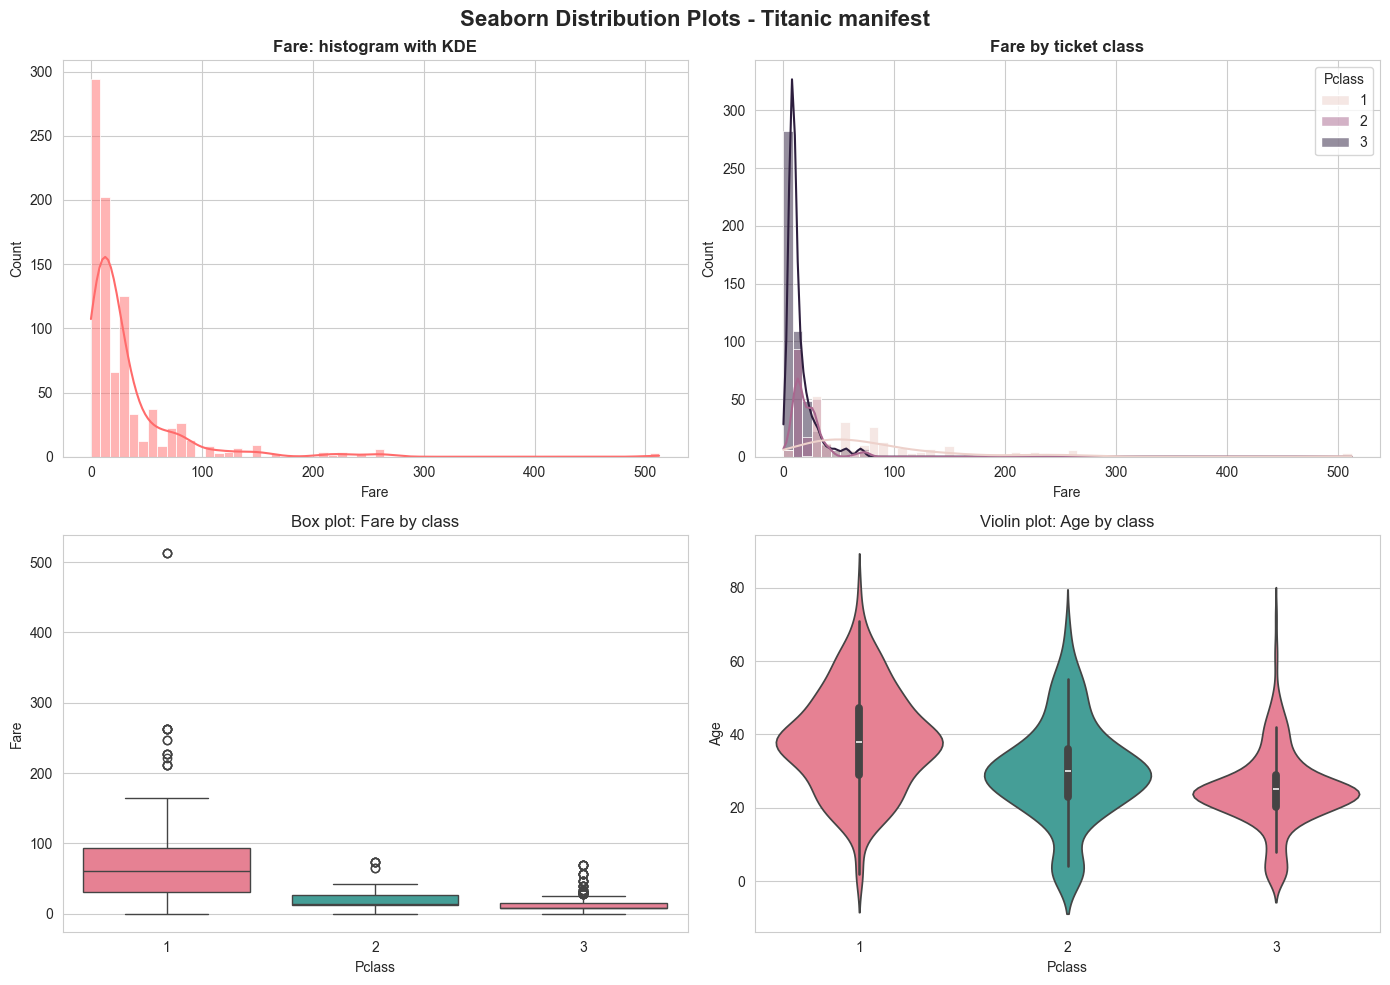

   The violin is the one to study: 3rd class is widest at the young end
   (median age 25) while 1st class peaks much later (38).
   A box plot would have shown the medians but hidden those shapes.


In [3]:
# WHAT: Draw four distribution views - histogram+KDE, by-category histogram, box, violin.
# WHY: Each reveals something different: KDE the shape, box the quartiles/outliers, violin the full density per group.

print("\n2. Distribution Plots")
print("-" * 70)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Seaborn Distribution Plots - Titanic manifest', fontsize=16, weight='bold')
# Histogram with KDE
sns.histplot(data=df, x='Fare', kde=True, ax=axes[0, 0], color='#FF6B6B')
axes[0, 0].set_title('Fare: histogram with KDE', fontsize=12, weight='bold')
# Distribution by category
sns.histplot(data=df, x='Fare', hue='Pclass', kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Fare by ticket class', fontsize=12, weight='bold')
# Box plot
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Pclass', ax=axes[1, 0],
            palette='husl', legend=False)
axes[1, 0].set_title('Box plot: Fare by class')
# Violin plot
sns.violinplot(data=df, x='Pclass', y='Age', hue='Pclass', ax=axes[1, 1],
               palette='husl', legend=False)
axes[1, 1].set_title('Violin plot: Age by class')
plt.tight_layout()
plt.savefig('06_distribution_plots.png', dpi=300, bbox_inches='tight')
print("✓ Distribution plots saved")
plt.show()
print("   The violin is the one to study: 3rd class is widest at the young end")
print(f"   (median age {df[df['Pclass'] == 3]['Age'].median():.0f}) while 1st class"
      f" peaks much later ({df[df['Pclass'] == 1]['Age'].median():.0f}).")
print("   A box plot would have shown the medians but hidden those shapes.")


## Part 3: Categorical Plots

**BEFORE**: You can plot distributions but not compare categories easily.

**AFTER**: You'll create bar plots, count plots, and strip plots to compare categories!

**Why this matters**: Categorical plots help you compare groups - essential for data analysis!

## Step 3: Creating Categorical Plots

**BEFORE**: We need to compare categories but don't have specialized plots.

**AFTER**: We'll create bar plots, count plots, and grouped comparisons!


3. Categorical Plots
----------------------------------------------------------------------


/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_65603/2902727516.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 0].legend(title='Sex')


✓ Categorical plots saved


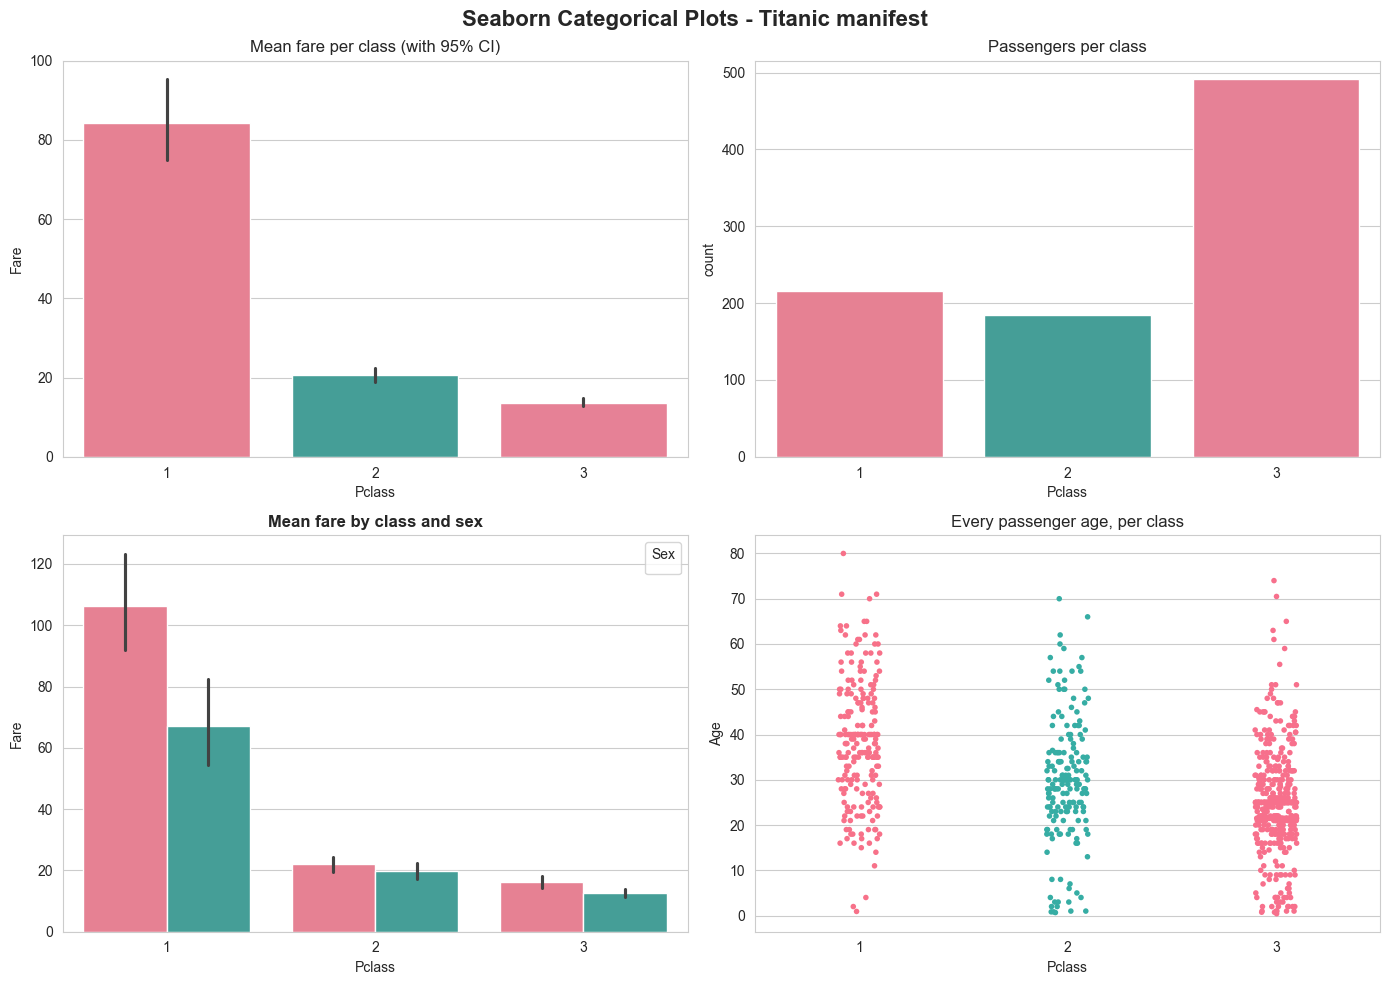

   Note what barplot draws automatically: the black whisker on each bar is a
   95% confidence interval for the mean, bootstrapped by seaborn. On 1st
   class it is wide, because a handful of 512-pound tickets make that mean
   genuinely uncertain. A plain bar chart would have hidden that doubt.


In [4]:
# WHAT: Draw four categorical views - bar, count, grouped bar, strip.
# WHY: Bar plots show a mean with its confidence interval, count plots show frequencies, strips show every raw point.

print("\n3. Categorical Plots")
print("-" * 70)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Seaborn Categorical Plots - Titanic manifest', fontsize=16, weight='bold')
# Bar plot
sns.barplot(data=df, x='Pclass', y='Fare', hue='Pclass', ax=axes[0, 0],
            palette='husl', legend=False)
axes[0, 0].set_title('Mean fare per class (with 95% CI)')
# Count plot
sns.countplot(data=df, x='Pclass', hue='Pclass', ax=axes[0, 1],
              palette='husl', legend=False)
axes[0, 1].set_title('Passengers per class')
# Grouped bar plot
sns.barplot(data=df, x='Pclass', y='Fare', hue='Sex', ax=axes[1, 0], palette='husl', legend=False)
axes[1, 0].set_title('Mean fare by class and sex', fontsize=12, weight='bold')
axes[1, 0].legend(title='Sex')
# Strip plot
sns.stripplot(data=df, x='Pclass', y='Age', hue='Pclass', ax=axes[1, 1],
              palette='husl', size=4, legend=False)
axes[1, 1].set_title('Every passenger age, per class')
plt.tight_layout()
plt.savefig('07_categorical_plots.png', dpi=300, bbox_inches='tight')
print("✓ Categorical plots saved")
plt.show()
print("   Note what barplot draws automatically: the black whisker on each bar is a")
print("   95% confidence interval for the mean, bootstrapped by seaborn. On 1st")
print("   class it is wide, because a handful of 512-pound tickets make that mean")
print("   genuinely uncertain. A plain bar chart would have hidden that doubt.")


## Part 4: Relationship Plots

**BEFORE**: You can plot individual variables but not their relationships.

**AFTER**: You'll create scatter plots, regression plots, and correlation visualizations!

**Why this matters**: Understanding relationships between variables is key to data science!

## Step 4: Creating Relationship Plots

**BEFORE**: We need to see relationships but don't have relationship-focused plots.

**AFTER**: We'll create scatter plots with regression lines to see correlations!


4. Relationship Plots
----------------------------------------------------------------------


✓ Relationship plots saved


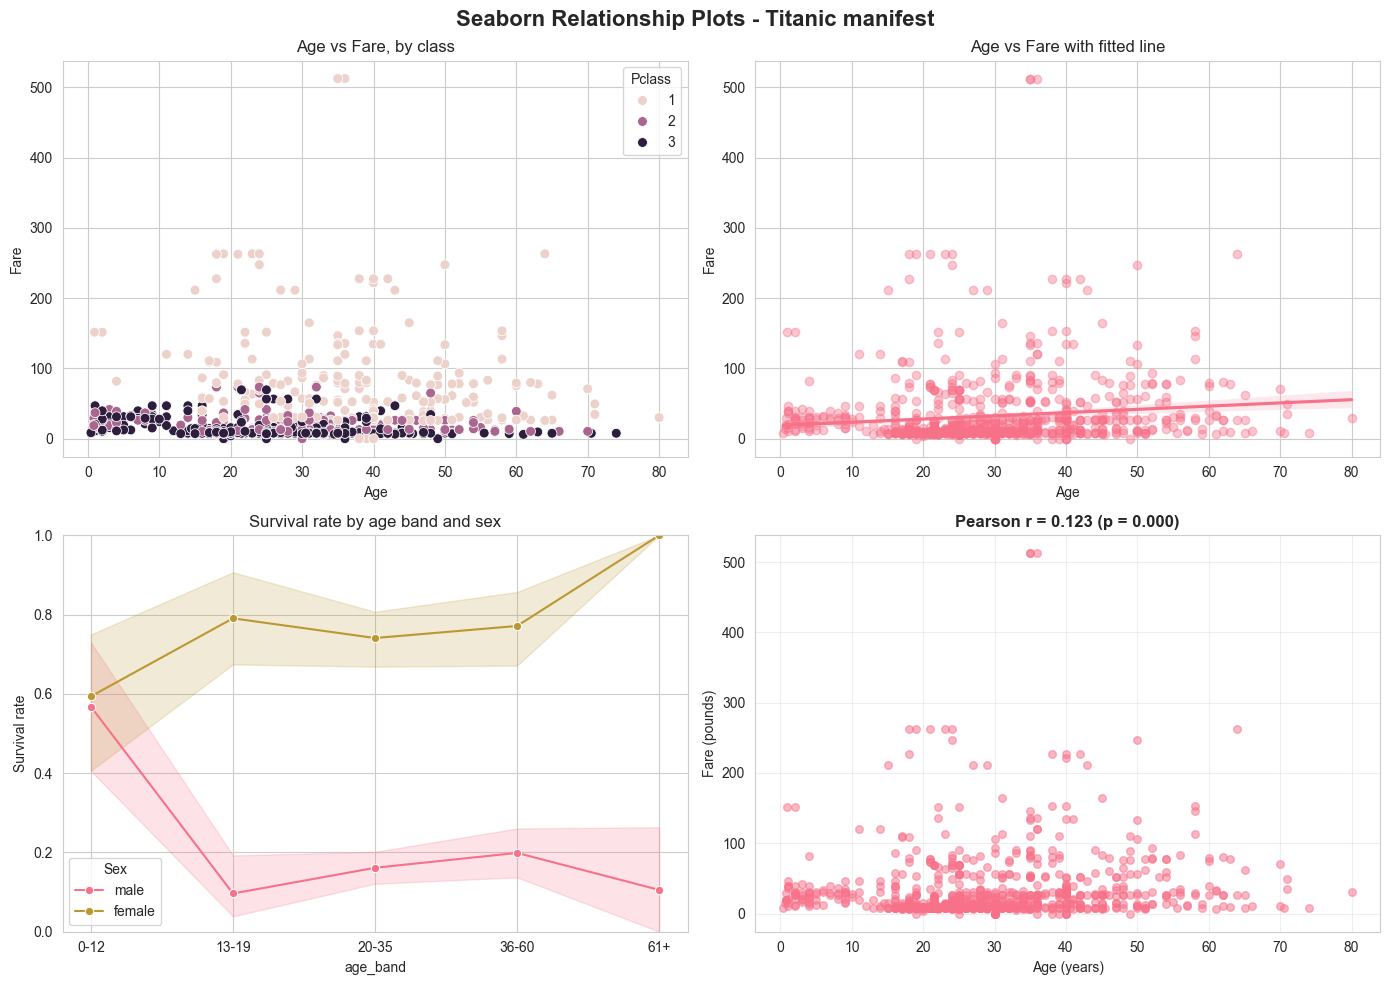

   Age vs Fare: r = 0.123. Statistically distinguishable from zero (p = 0.000),
   but far too weak to predict anything with. Report both numbers - a tiny
   effect can be 'significant' on 891 rows and still be useless.
   The bottom-left panel is where the real signal is: the two sexes have
   completely different survival curves at every age.


In [5]:
# WHAT: Draw relationship views - scatter with hue, regression fit, a survival-rate line, and a correlation-labeled scatter.
# WHY: regplot adds a fitted line with an uncertainty band - an instant, honest first check of a linear relationship.

print("\n4. Relationship Plots")
print("-" * 70)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Seaborn Relationship Plots - Titanic manifest', fontsize=16, weight='bold')

# Scatter plot: two numbers, coloured by a category
sns.scatterplot(data=df, x='Age', y='Fare', hue='Pclass', ax=axes[0, 0], s=50)
axes[0, 0].set_title('Age vs Fare, by class')

# Regression plot: the same pair with a fitted line and its uncertainty band
sns.regplot(data=df, x='Age', y='Fare', ax=axes[0, 1], scatter_kws={'alpha': 0.4})
axes[0, 1].set_title('Age vs Fare with fitted line')

# Line plot: survival rate across age bands, split by sex.
# seaborn averages Survived (a 0/1 column) within each band and draws a 95% CI.
sns.lineplot(data=df, x='age_band', y='Survived', hue='Sex', marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Survival rate by age band and sex')
axes[1, 0].set_ylabel('Survival rate')
axes[1, 0].set_ylim(0, 1)

# The same scatter, labelled with the measured correlation
corr, p_value = pearsonr(df['Age'], df['Fare'])
axes[1, 1].scatter(df['Age'], df['Fare'], alpha=0.5, s=30)
axes[1, 1].set_xlabel('Age (years)')
axes[1, 1].set_ylabel('Fare (pounds)')
axes[1, 1].set_title(f'Pearson r = {corr:.3f} (p = {p_value:.3f})',
                     fontsize=12, weight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('08_relationship_plots.png', dpi=300, bbox_inches='tight')
print("✓ Relationship plots saved")
plt.show()
print(f"   Age vs Fare: r = {corr:.3f}. Statistically distinguishable from zero"
      f" (p = {p_value:.3f}),")
print("   but far too weak to predict anything with. Report both numbers - a tiny")
print("   effect can be 'significant' on 891 rows and still be useless.")
print("   The bottom-left panel is where the real signal is: the two sexes have")
print("   completely different survival curves at every age.")


## Part 5: Heatmaps and Correlation

**BEFORE**: You can plot relationships but not see correlation matrices easily.

**AFTER**: You'll create heatmaps to visualize correlations across multiple variables!

**Why this matters**: Heatmaps show patterns across entire datasets - powerful for exploration!

## Step 5: Creating Heatmaps

**BEFORE**: We need to see correlations but individual plots are too slow.

**AFTER**: We'll create correlation heatmaps to see all relationships at once!


5. Heatmaps and Correlation
----------------------------------------------------------------------


✓ Heatmaps saved


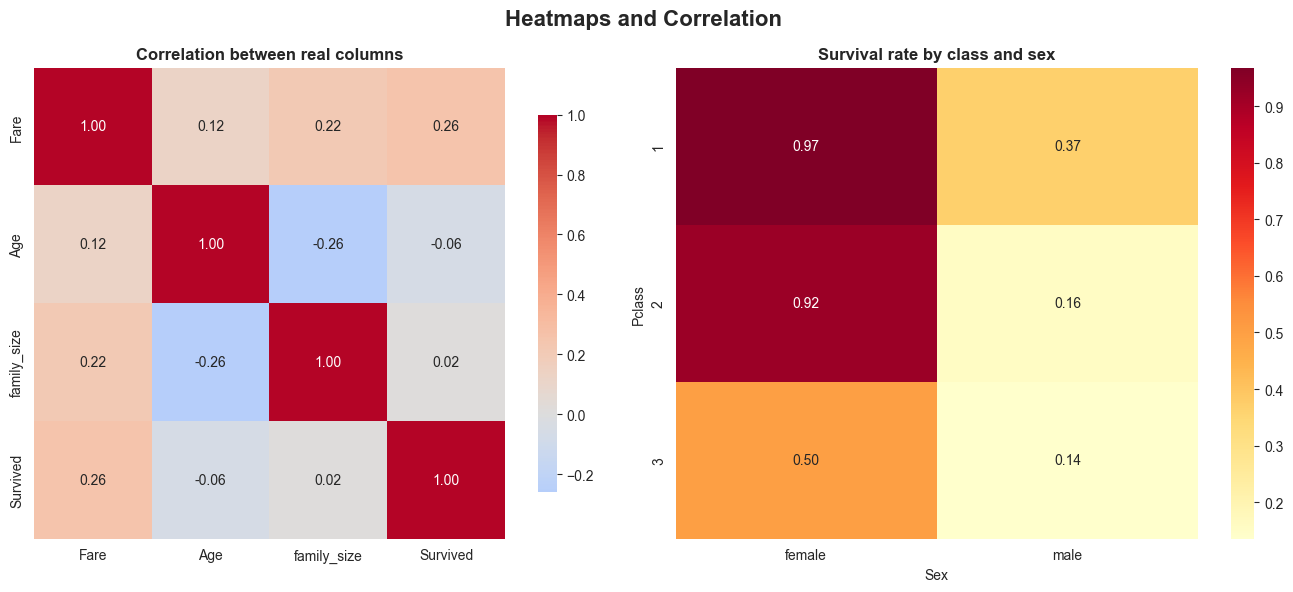

   The right-hand grid is the whole tragedy in six numbers:
Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135
   A 1st-class woman survived at 97%; a 3rd-class man at 14%.


In [6]:
# WHAT: Draw a correlation heatmap and a pivot-table heatmap.
# WHY: Heatmaps turn number grids into color patterns your eye can scan instantly.

print("\n5. Heatmaps and Correlation")
print("-" * 70)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Heatmaps and Correlation', fontsize=16, weight='bold')
# Correlation heatmap
numeric_cols = ['Fare', 'Age', 'family_size', 'Survived']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation between real columns', fontsize=12, weight='bold')
# Pivot table heatmap
pivot_data = df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean')
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Survival rate by class and sex', fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig('09_heatmaps.png', dpi=300, bbox_inches='tight')
print("✓ Heatmaps saved")
plt.show()
print("   The right-hand grid is the whole tragedy in six numbers:")
print(pivot_data.round(3).to_string())
print(f"   A 1st-class woman survived at"
      f" {pivot_data.loc[1, 'female']:.0%}; a 3rd-class man at"
      f" {pivot_data.loc[3, 'male']:.0%}.")


## Part 6: Pair Plots

**BEFORE**: You can plot relationships one at a time but not all at once.

**AFTER**: You'll create pair plots to see all variable relationships simultaneously!

**Why this matters**: Pair plots are perfect for exploratory data analysis!

## Step 6: Creating Pair Plots

**BEFORE**: We can plot relationships individually but need to see all at once.

**AFTER**: We'll create pair plots showing all variable relationships in one figure!


6. Pair Plot
----------------------------------------------------------------------


✓ Pair plot saved


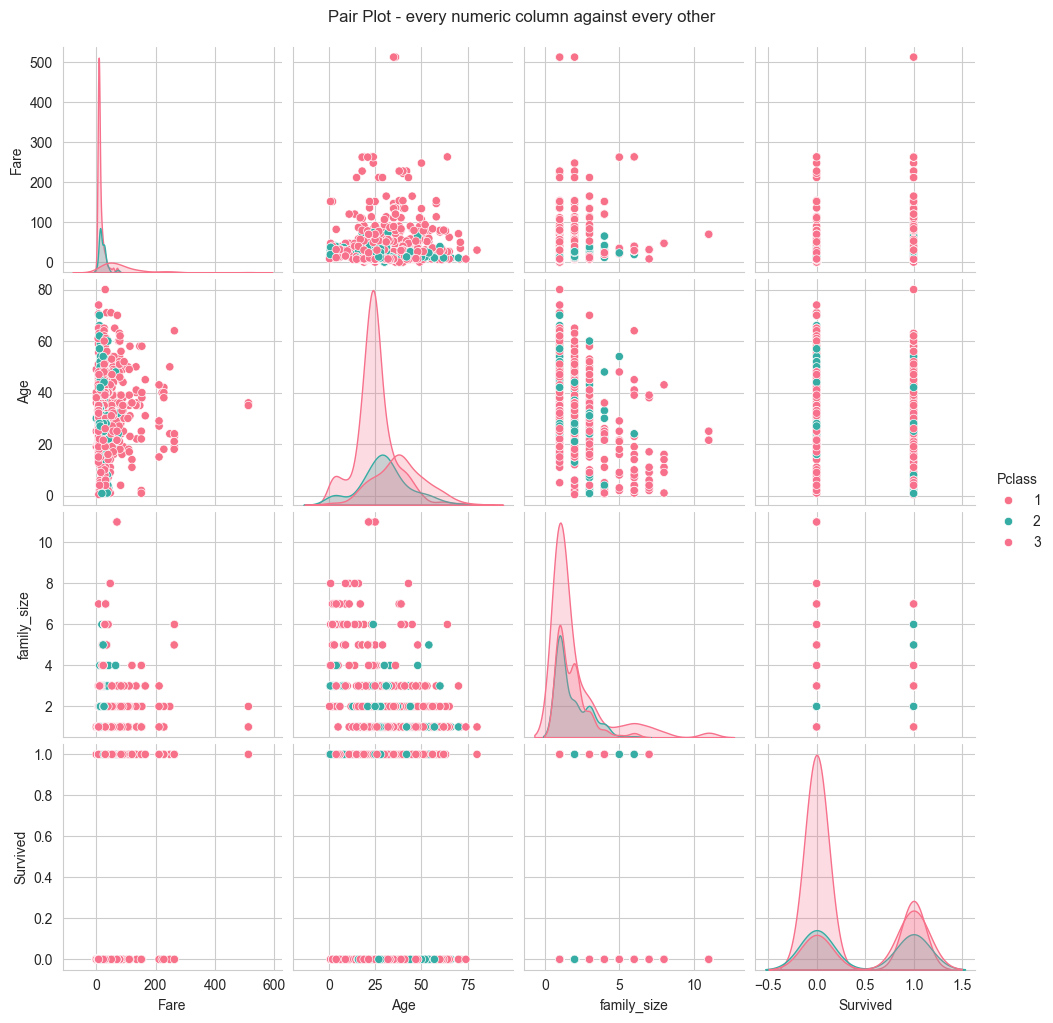

In [7]:
# WHAT: Draw a pair plot of all numeric columns colored by category.
# WHY: One command surveys every pairwise relationship plus each distribution - the fastest EDA overview there is.

print("\n6. Pair Plot")
print("-" * 70)
pair_plot = sns.pairplot(df[numeric_cols + ['Pclass']], hue='Pclass', palette='husl')
pair_plot.fig.suptitle('Pair Plot - every numeric column against every other', y=1.02)
pair_plot.savefig('10_pair_plot.png', dpi=300, bbox_inches='tight')
print("✓ Pair plot saved")
plt.show()


## 🎯 Summary: What We Learned

## Final Summary

In [8]:
# WHAT: Print a recap of the seaborn plot families.
# WHY: Knowing which family answers which question is the real skill; the syntax is a lookup away.

print("\n" + "=" * 70)
print("🎯 SUMMARY: What We Learned")
print("=" * 70)

print("\n📋 BEFORE this notebook:")
print("   - You could create basic plots with matplotlib")
print("   - You didn't know how to create statistical visualizations easily")
print("   - You couldn't explore data relationships quickly")

print("\n✅ AFTER this notebook:")
print("   - You can create distribution plots (histograms, KDE, box, violin)")
print("   - You can create categorical plots (bar, count, grouped)")
print("   - You can create relationship plots (scatter, regression, correlation)")
print("   - You can create heatmaps for correlation matrices")
print("   - You can create pair plots for multivariate analysis")

print("\n📚 Key Concepts Covered:")
print("   1. Distribution Plots (understand how data is distributed)")
print("   2. Categorical Plots (compare groups and categories)")
print("   3. Relationship Plots (see correlations and trends)")
print("   4. Heatmaps (visualize correlation matrices)")
print("   5. Pair Plots (explore all relationships at once)")

print("\n🔗 Where Seaborn Fits:")
print("   - Built on matplotlib (uses matplotlib under the hood)")
print("   - Perfect for statistical visualizations")
print("   - Beautiful defaults with minimal code")
print("   - Essential for exploratory data analysis")

print("\n➡️  Next Steps:")
print("   - Continue to Example 4: Plotly Interactive Visualizations")
print("   - You'll learn interactive plots (different from static Seaborn)")
print("   - Your Seaborn knowledge helps you understand visualization principles!")

print("\n" + "=" * 70)
plt.show()


🎯 SUMMARY: What We Learned

📋 BEFORE this notebook:
   - You could create basic plots with matplotlib
   - You didn't know how to create statistical visualizations easily
   - You couldn't explore data relationships quickly

✅ AFTER this notebook:
   - You can create distribution plots (histograms, KDE, box, violin)
   - You can create categorical plots (bar, count, grouped)
   - You can create relationship plots (scatter, regression, correlation)
   - You can create heatmaps for correlation matrices
   - You can create pair plots for multivariate analysis

📚 Key Concepts Covered:
   1. Distribution Plots (understand how data is distributed)
   2. Categorical Plots (compare groups and categories)
   3. Relationship Plots (see correlations and trends)
   4. Heatmaps (visualize correlation matrices)
   5. Pair Plots (explore all relationships at once)

🔗 Where Seaborn Fits:
   - Built on matplotlib (uses matplotlib under the hood)
   - Perfect for statistical visualizations
   - Beautif

## 🚫 When Seaborn Hits a Dead End

**BEFORE**: We've learned Seaborn for beautiful statistical visualizations.

**AFTER**: We discover Seaborn creates static plots - we need interactive exploration!

**Why this matters**: Static plots are great for reports, but interactive plots enable exploration and dashboards!

---

### The Problem We've Discovered

We've learned:
- ✅ How to create beautiful statistical plots with Seaborn
- ✅ How to visualize distributions, relationships, and correlations
- ✅ How to create heatmaps and pair plots

**But we have a problem:**
- ❓ **What if we need to zoom, pan, or explore the data interactively?**
- ❓ **What if we need interactive dashboards for presentations?**
- ❓ **What if we want users to explore data themselves?**

**The Dead End:**
- Seaborn creates beautiful static plots (perfect for reports)
- But static plots can't be zoomed, panned, or explored interactively
- For data exploration and dashboards, we need interactive visualizations

---

### Demonstrating the Problem

Let's see the limitation of static plots:

In [9]:
# WHAT: List the limits of static images (no zoom, hover, or filters).
# WHY: These limits motivate Plotly in the next example - exploration wants interaction.

print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: Static Plots Limitation")
print("=" * 70)

print(f"\n📊 Current Visualization Capabilities:")
print(f"   ✓ Beautiful static plots (Seaborn)")
print(f"   ✓ Statistical visualizations")
print(f"   ✓ Publication-ready plots")

print(f"\n⚠️  Limitations of Static Plots:")
print(f"   ❌ Cannot zoom into specific regions")
print(f"   ❌ Cannot pan around the plot")
print(f"   ❌ Cannot hover to see exact values")
print(f"   ❌ Cannot filter data interactively")
print(f"   ❌ Cannot create interactive dashboards")
print(f"   ❌ Cannot share interactive visualizations online")

print(f"\n💡 The Problem:")
print(f"   - Static plots are perfect for reports and papers")
print(f"   - But for data exploration, we need interactivity")
print(f"   - For dashboards and presentations, we need interactive plots")
print(f"   - For sharing with others, interactive plots are more engaging")

print(f"\n📋 Real-World Scenarios Where Static Plots Fall Short:")
print(f"   1. Data Exploration: Need to zoom into clusters or outliers")
print(f"   2. Dashboards: Need interactive filters and selections")
print(f"   3. Presentations: Need to explore data live during presentation")
print(f"   4. Web Sharing: Need interactive plots that work in browsers")
print(f"   5. User Analysis: Need plots users can explore themselves")

print(f"\n➡️  Solution Needed:")
print(f"   - We need interactive visualization libraries")
print(f"   - We need plots that can be zoomed, panned, and explored")
print(f"   - We need dashboards with interactive controls")
print(f"   - This leads us to Example 4: Plotly Interactive Visualizations")

print("\n" + "=" * 70)


🚫 DEMONSTRATING THE DEAD END: Static Plots Limitation

📊 Current Visualization Capabilities:
   ✓ Beautiful static plots (Seaborn)
   ✓ Statistical visualizations
   ✓ Publication-ready plots

⚠️  Limitations of Static Plots:
   ❌ Cannot zoom into specific regions
   ❌ Cannot pan around the plot
   ❌ Cannot hover to see exact values
   ❌ Cannot filter data interactively
   ❌ Cannot create interactive dashboards
   ❌ Cannot share interactive visualizations online

💡 The Problem:
   - Static plots are perfect for reports and papers
   - But for data exploration, we need interactivity
   - For dashboards and presentations, we need interactive plots
   - For sharing with others, interactive plots are more engaging

📋 Real-World Scenarios Where Static Plots Fall Short:
   1. Data Exploration: Need to zoom into clusters or outliers
   2. Dashboards: Need interactive filters and selections
   3. Presentations: Need to explore data live during presentation
   4. Web Sharing: Need interactive 

### What We Need Next

**The Solution**: We need interactive visualization tools:
- **Plotly**: Interactive plotting library for Python
- **Interactive features**: Zoom, pan, hover, filter
- **Dashboards**: Create interactive web dashboards
- **Web-ready**: Works in browsers, shareable online

**This dead end leads us to Example 4: Plotly Interactive Visualizations**
- Example 4 will show us how to create interactive plots
- We'll see plots that can be zoomed, panned, and explored
- This solves the interactivity problem for data exploration and dashboards!


## 📚 References

1. Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
2. Wickham, H. (2010). *A Layered Grammar of Graphics*. Journal of Computational and Graphical Statistics, 19(1), 3-28. <https://doi.org/10.1198/jcgs.2009.07098>
3. Waskom, M. L. (2021). *seaborn: Statistical Data Visualization*. Journal of Open Source Software, 6(60), 3021. <https://joss.theoj.org/papers/10.21105/joss.03021>